In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import sys
from tqdm import tqdm
import pathlib
from pathlib import Path
import io
import contextlib
import re
from glob import glob
import os

In [2]:
plt.style.use('publication.rc')

In [4]:
run_id = 24
f_names = ['/Users/gracetytus/gaps/checkouts/rbe_per_evtid' + str(run_id) + '.txt']

In [5]:
with open(f_names[0]) as in_file:
    variables = next(in_file).strip().split(',')

# Determine total number of lines
num_lines = -len(f_names)
for name in f_names:
    with open(name) as in_file:
        num_lines += sum(1 for _ in in_file)

# Initialize data dictionary with zeros
data_dict = {}
for var in variables:
    data_dict[var] = np.zeros(num_lines)

# Populate the data dictionary
k = 0
progress_bar = tqdm(total=num_lines)
for name in f_names:
    with open(name) as in_file:
        next(in_file)  # Skip header
        for line in in_file:
            for j, dat in enumerate(line.strip().split(',')):
                # Handle empty strings by assigning a default value
                try:
                    data_dict[variables[j]][k] = float(dat) if dat else np.nan  # Replace np.nan with 0 if needed
                except ValueError:
                    print(f"Skipping invalid value '{dat}' in file {name}, line {k}")
                    data_dict[variables[j]][k] = np.nan  # Default to NaN
            k += 1
            progress_bar.update(1)

progress_bar.close()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25759546/25759546 [00:39<00:00, 647001.66it/s]


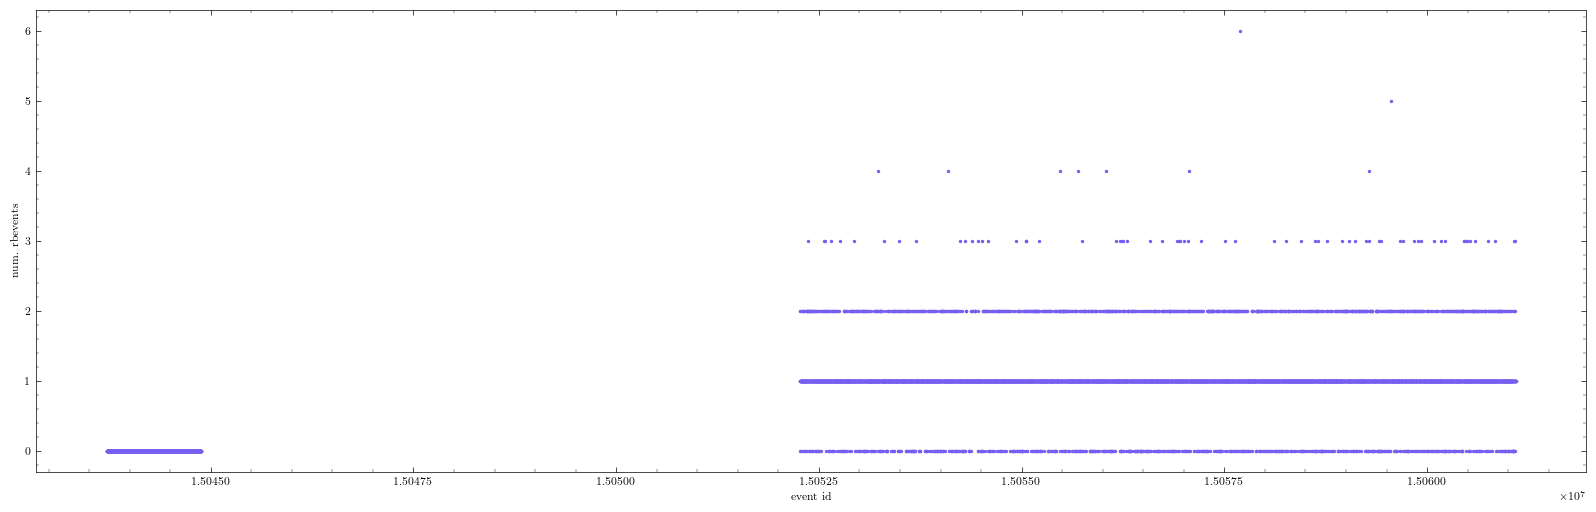

In [21]:
plt.figure(figsize = (20,6))
plt.scatter(data_dict['evtid'][:10000], data_dict['num_rbe'][:10000], s = 2)
#plt.title('Paddle 97B charge over time')
plt.xlabel('event id')
plt.ylabel('num. rbevents')
plt.minorticks_on()
plt.show()

In [15]:
len(data_dict['num_rbe'])

25759546

In [27]:
skipped_rb = 0
for i in data_dict['num_rbe']:
    if i == 0.0:
        skipped_rb += 1

In [30]:
skipped_rb / len(data_dict['num_rbe'])  * 100

10.021550845655431

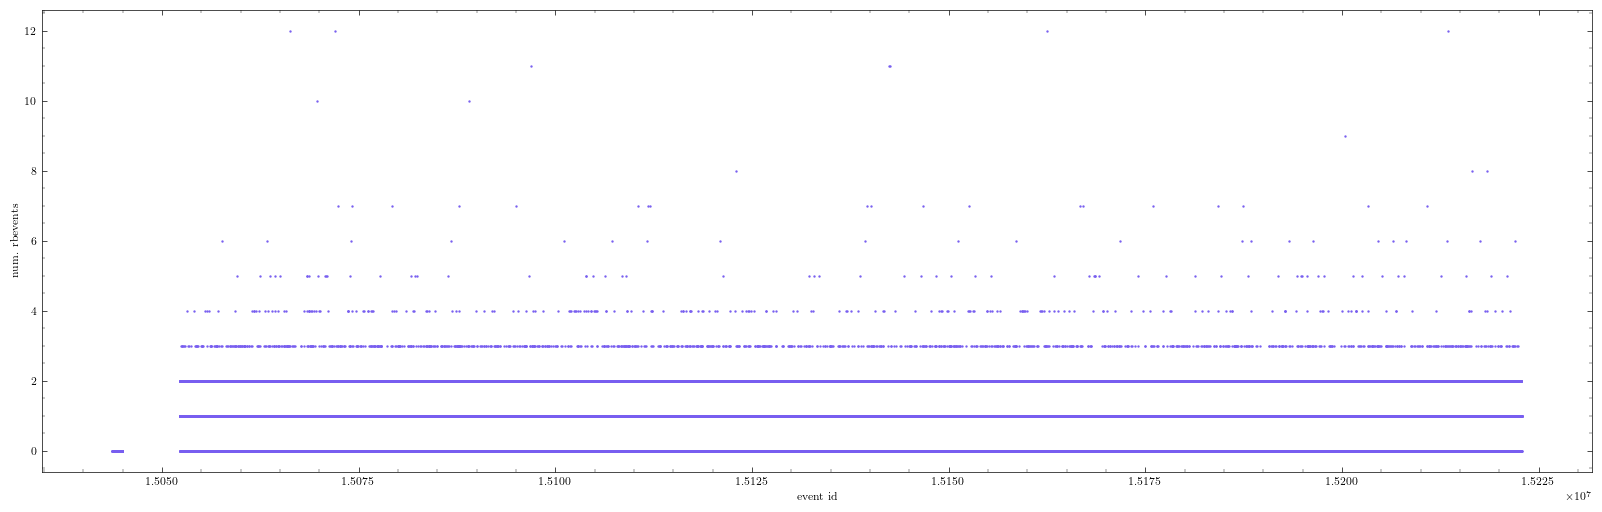

In [31]:
plt.figure(figsize = (20,6))
plt.scatter(data_dict['evtid'][:171703], data_dict['num_rbe'][:171703], s = 0.5)
#plt.title('Paddle 97B charge over time')
plt.xlabel('event id')
plt.ylabel('num. rbevents')
plt.minorticks_on()
plt.show()

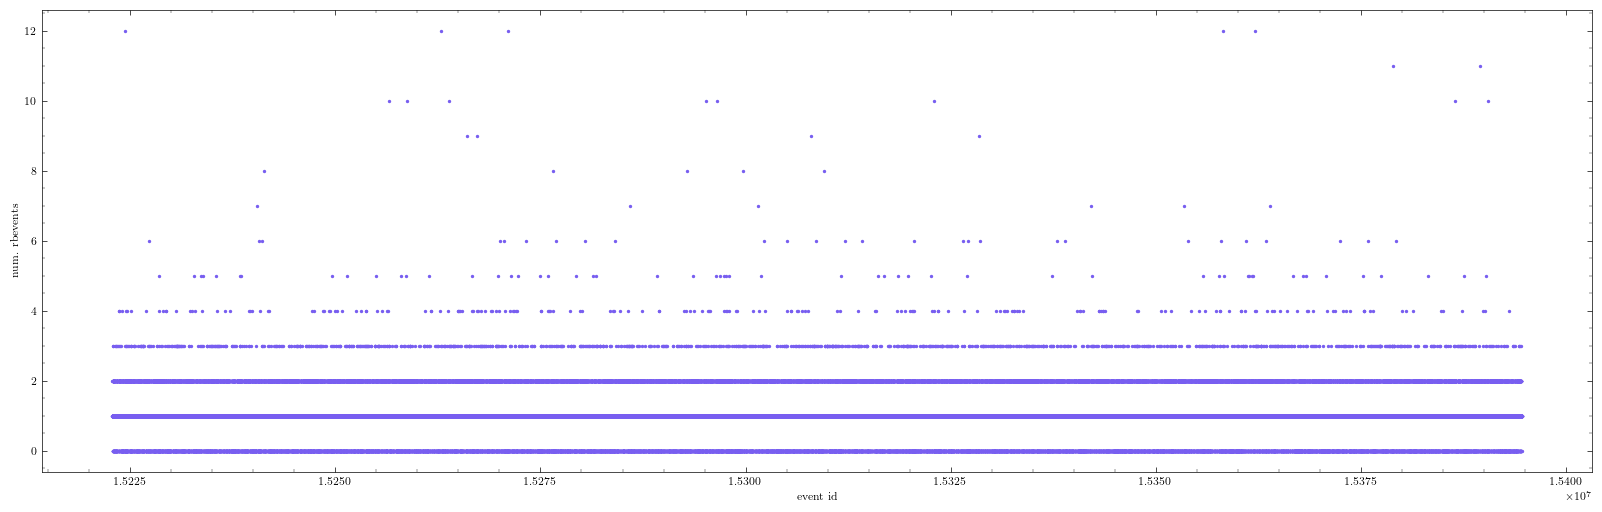

In [33]:
plt.figure(figsize = (20,6))
plt.scatter(data_dict['evtid'][171704:343407], data_dict['num_rbe'][171704:343407], s = 2)
#plt.title('Paddle 97B charge over time')
plt.xlabel('event id')
plt.ylabel('num. rbevents')
plt.minorticks_on()
plt.show()

In [63]:
171704 + 171703 + 171703 + 171703 + 171703 + 171703 + 171703 + 171703 + 171703 + 171703 + 171703 + 171703 + 171703 + 171703 + 171703 + 171703

2747249

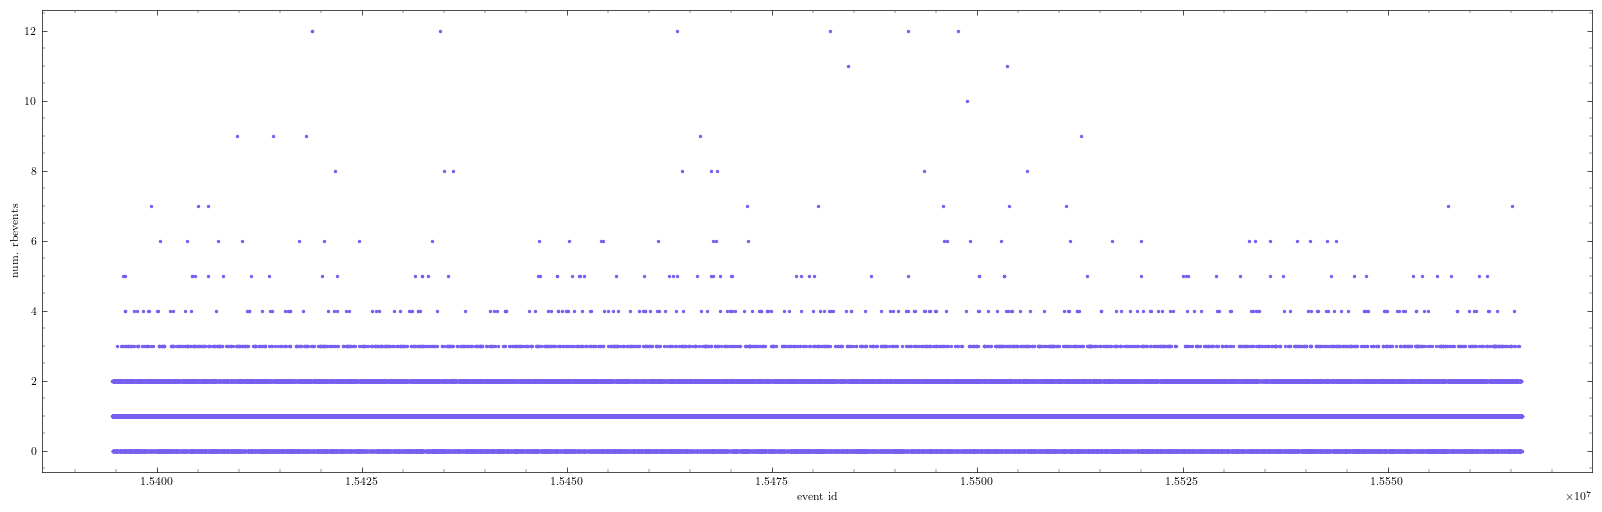

In [35]:
plt.figure(figsize = (20,6))
plt.scatter(data_dict['evtid'][343408:515110], data_dict['num_rbe'][343408:515110], s = 2)
#plt.title('Paddle 97B charge over time')
plt.xlabel('event id')
plt.ylabel('num. rbevents')
plt.minorticks_on()
plt.show()

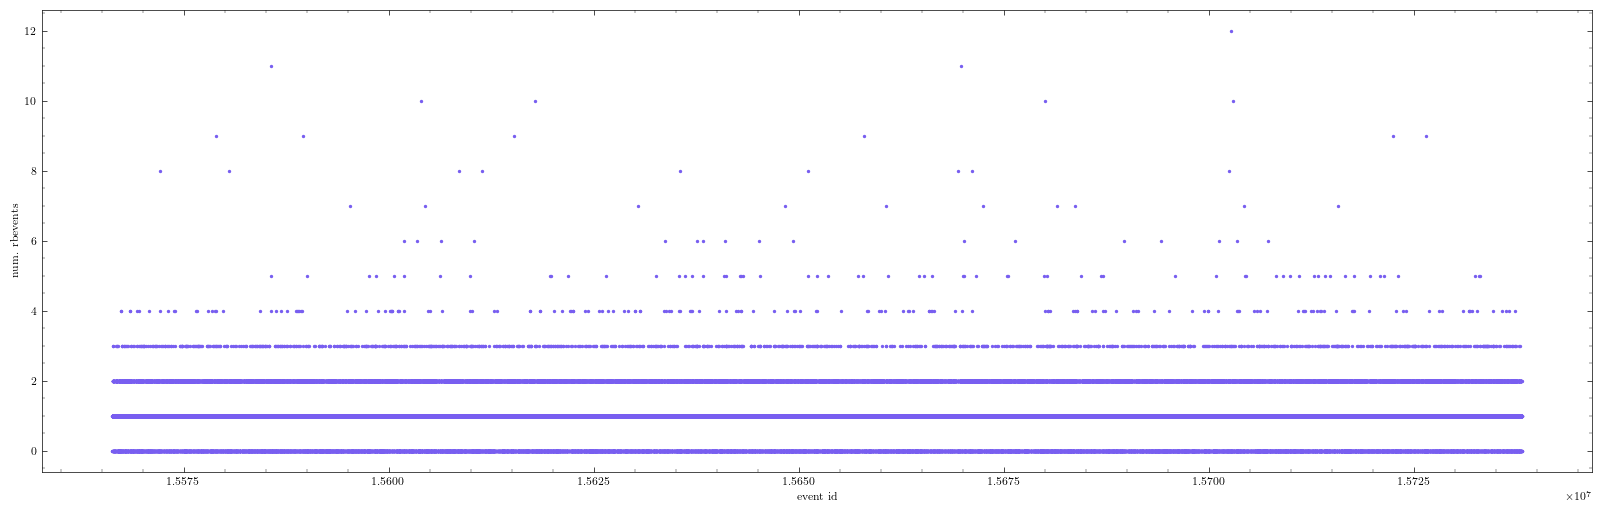

In [37]:
plt.figure(figsize = (20,6))
plt.scatter(data_dict['evtid'][515111:686813], data_dict['num_rbe'][515111:686813], s = 2)
#plt.title('Paddle 97B charge over time')
plt.xlabel('event id')
plt.ylabel('num. rbevents')
plt.minorticks_on()
plt.show()

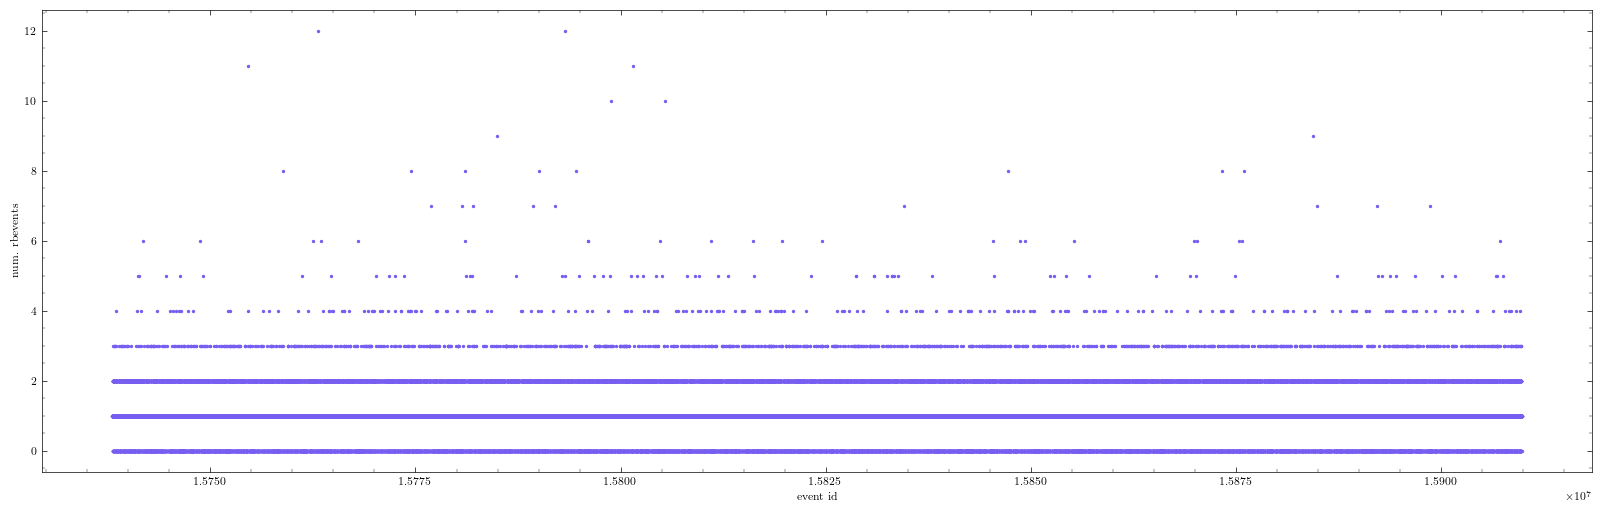

In [39]:
plt.figure(figsize = (20,6))
plt.scatter(data_dict['evtid'][686814:858516], data_dict['num_rbe'][686814:858516], s = 2)
#plt.title('Paddle 97B charge over time')
plt.xlabel('event id')
plt.ylabel('num. rbevents')
plt.minorticks_on()
plt.show()

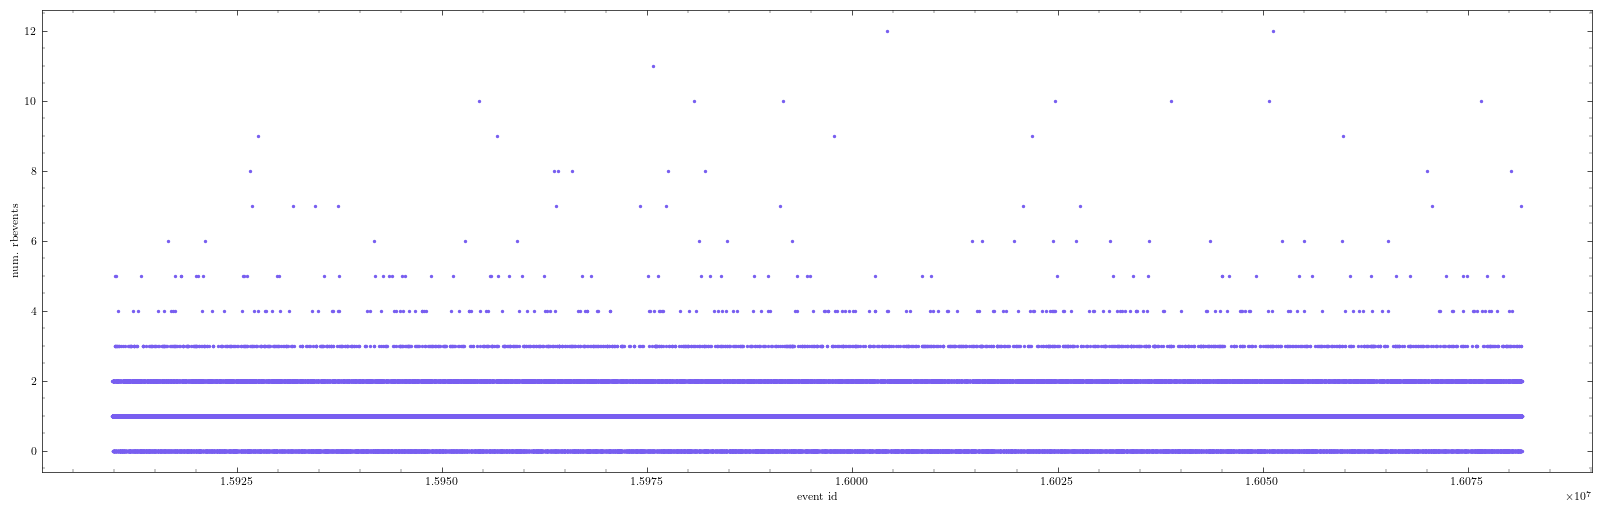

In [41]:
plt.figure(figsize = (20,6))
plt.scatter(data_dict['evtid'][858517:1030219], data_dict['num_rbe'][858517:1030219], s = 2)
#plt.title('Paddle 97B charge over time')
plt.xlabel('event id')
plt.ylabel('num. rbevents')
plt.minorticks_on()
plt.show()

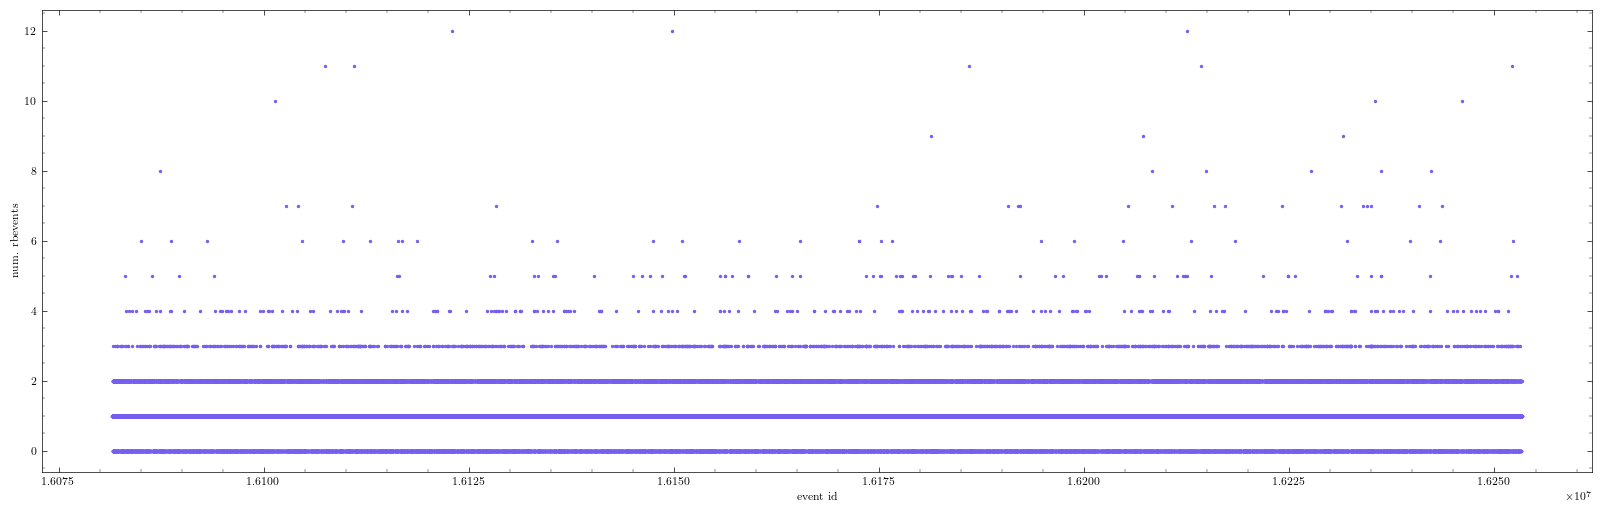

In [44]:
plt.figure(figsize = (20,6))
plt.scatter(data_dict['evtid'][1030220:1201922], data_dict['num_rbe'][1030220:1201922], s = 2)
#plt.title('Paddle 97B charge over time')
plt.xlabel('event id')
plt.ylabel('num. rbevents')
plt.minorticks_on()
plt.show()

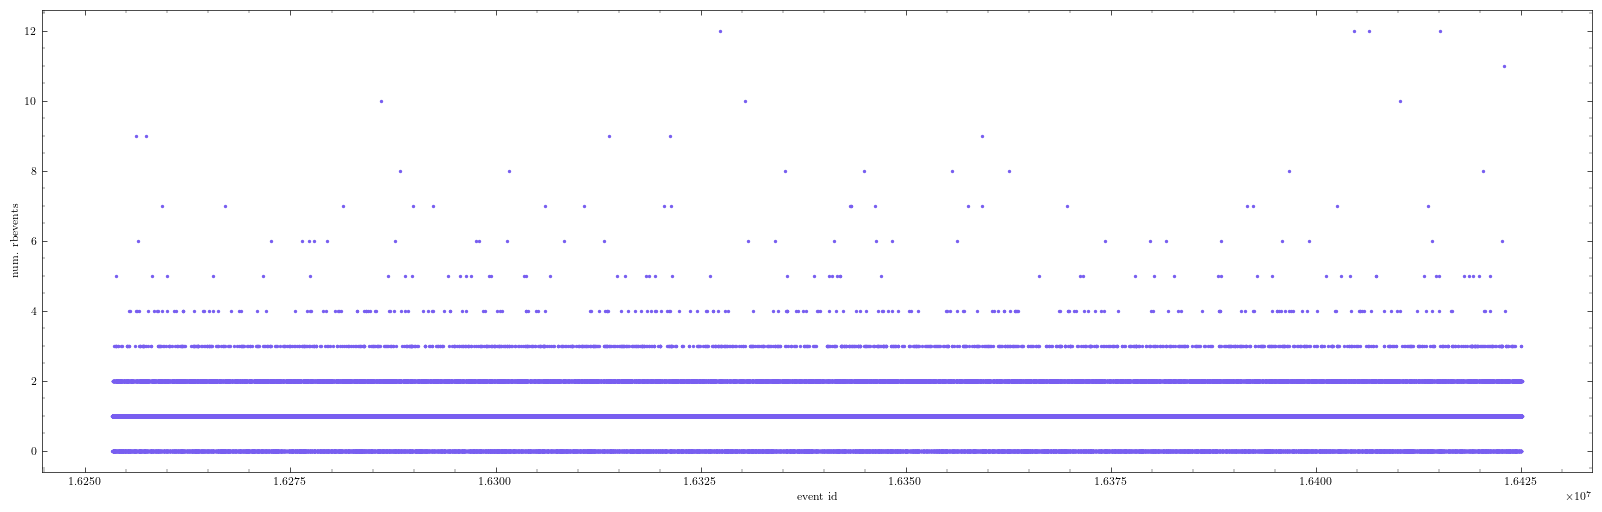

In [46]:
plt.figure(figsize = (20,6))
plt.scatter(data_dict['evtid'][1201923:1373625], data_dict['num_rbe'][1201923:1373625], s = 2)
#plt.title('Paddle 97B charge over time')
plt.xlabel('event id')
plt.ylabel('num. rbevents')
plt.minorticks_on()
plt.show()

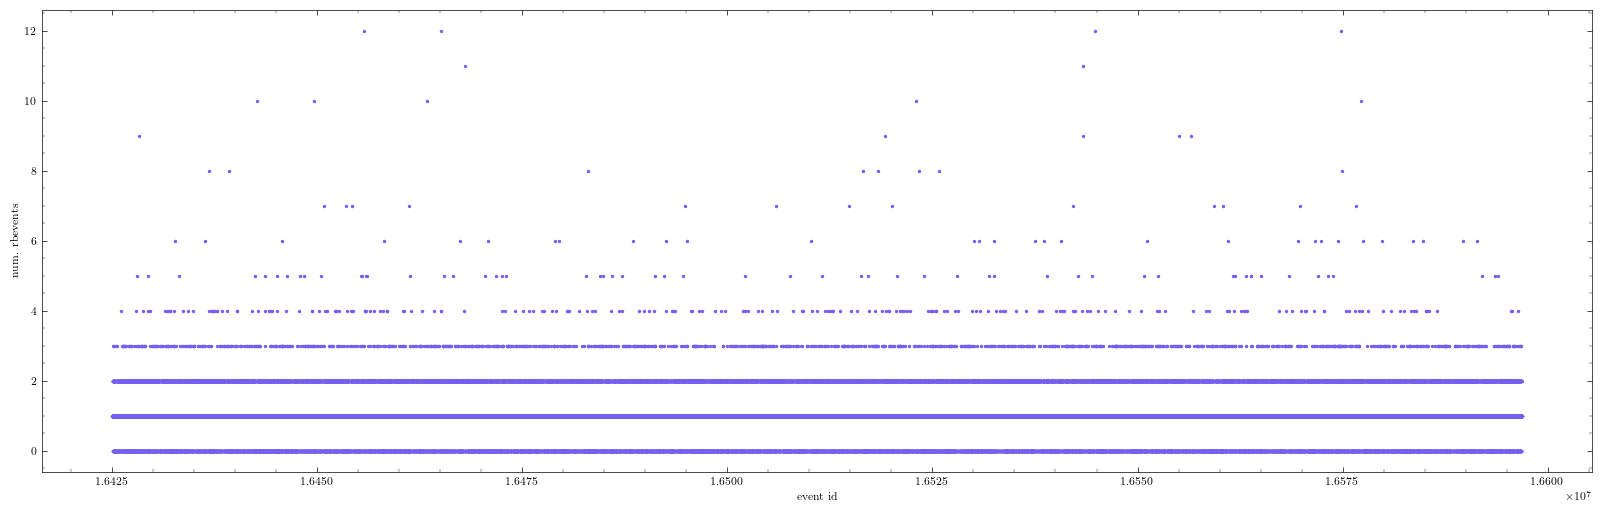

In [50]:
plt.figure(figsize = (20,6))
plt.scatter(data_dict['evtid'][1373626:1545328], data_dict['num_rbe'][1373626:1545328], s = 2)
#plt.title('Paddle 97B charge over time')
plt.xlabel('event id')
plt.ylabel('num. rbevents')
plt.minorticks_on()
plt.show()

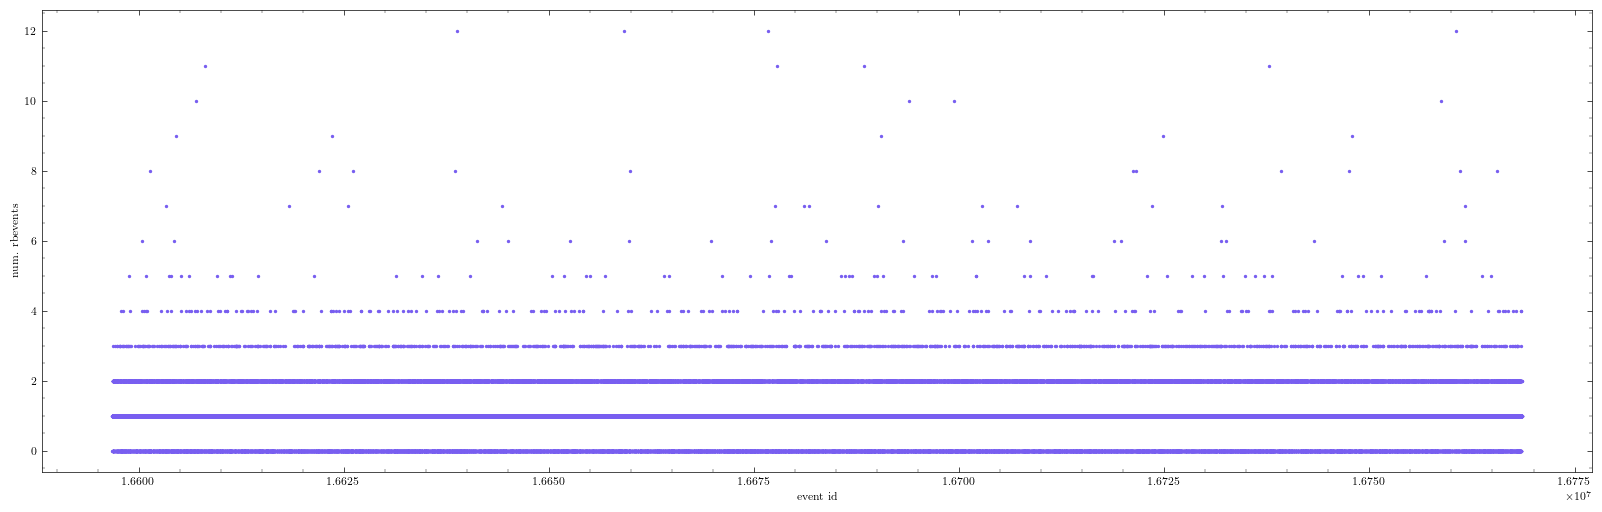

In [52]:
plt.figure(figsize = (20,6))
plt.scatter(data_dict['evtid'][1545329:1717031], data_dict['num_rbe'][1545329:1717031], s = 2)
#plt.title('Paddle 97B charge over time')
plt.xlabel('event id')
plt.ylabel('num. rbevents')
plt.minorticks_on()
plt.show()

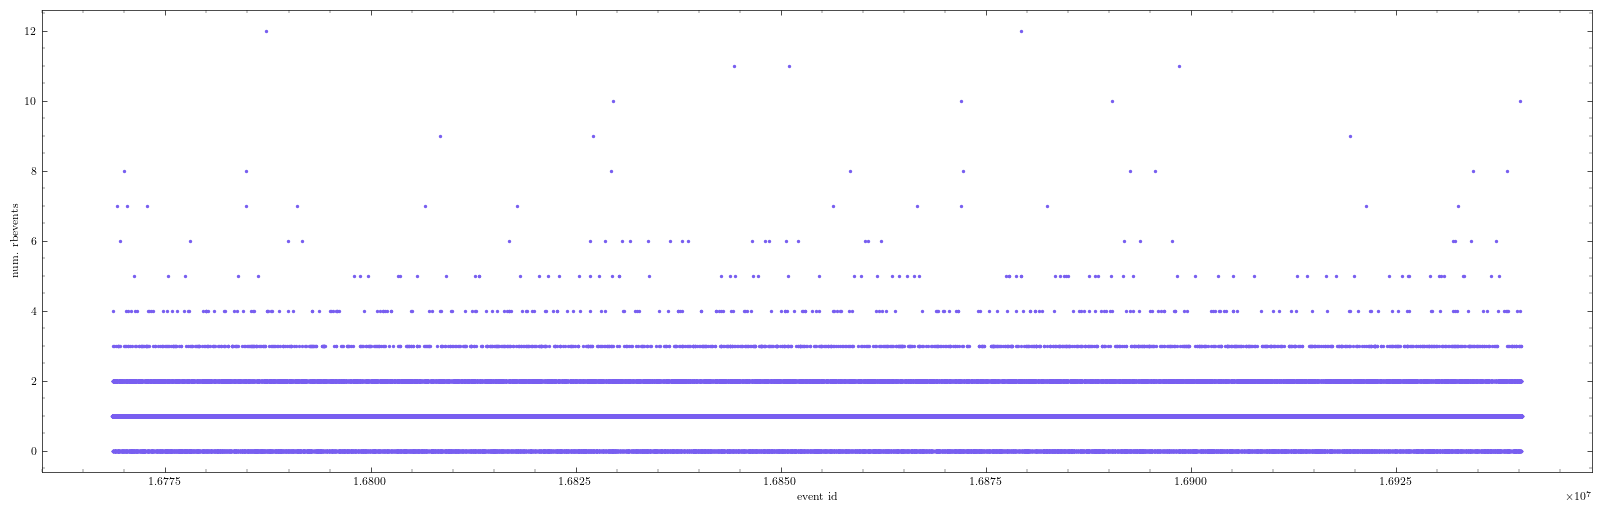

In [54]:
plt.figure(figsize = (20,6))
plt.scatter(data_dict['evtid'][1717032:1888734], data_dict['num_rbe'][1717032:1888734], s = 2)
#plt.title('Paddle 97B charge over time')
plt.xlabel('event id')
plt.ylabel('num. rbevents')
plt.minorticks_on()
plt.show()

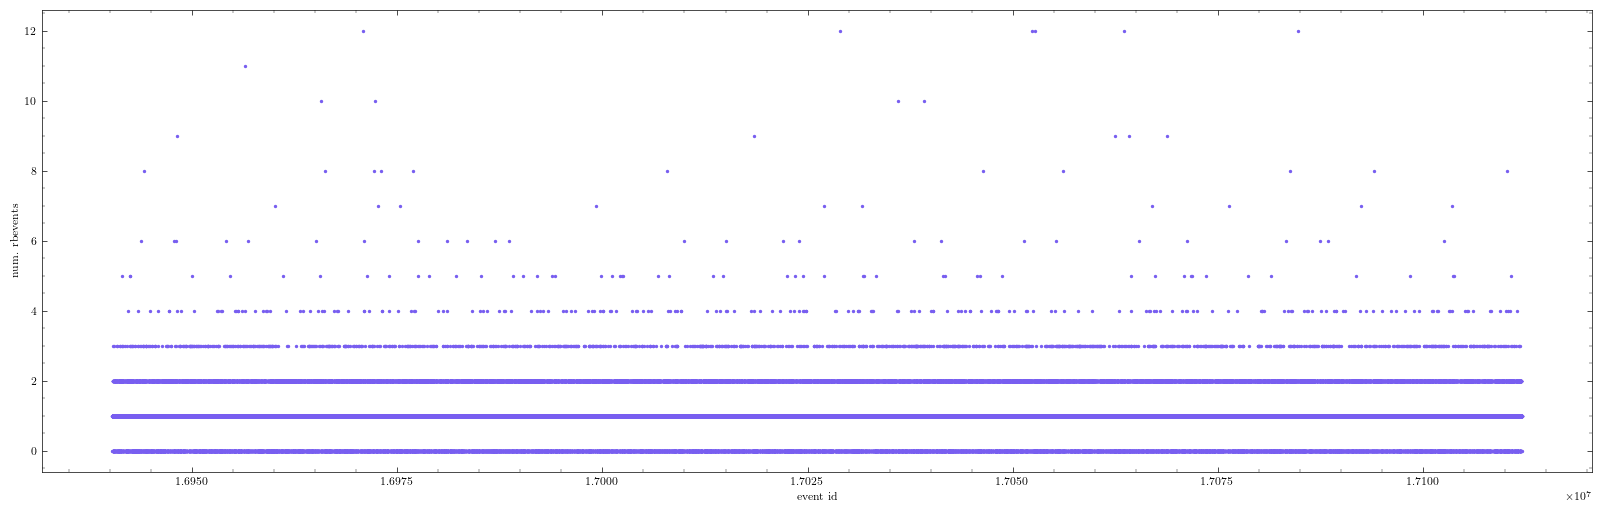

In [56]:
plt.figure(figsize = (20,6))
plt.scatter(data_dict['evtid'][1888735:2060437], data_dict['num_rbe'][1888735:2060437], s = 2)
#plt.title('Paddle 97B charge over time')
plt.xlabel('event id')
plt.ylabel('num. rbevents')
plt.minorticks_on()
plt.show()

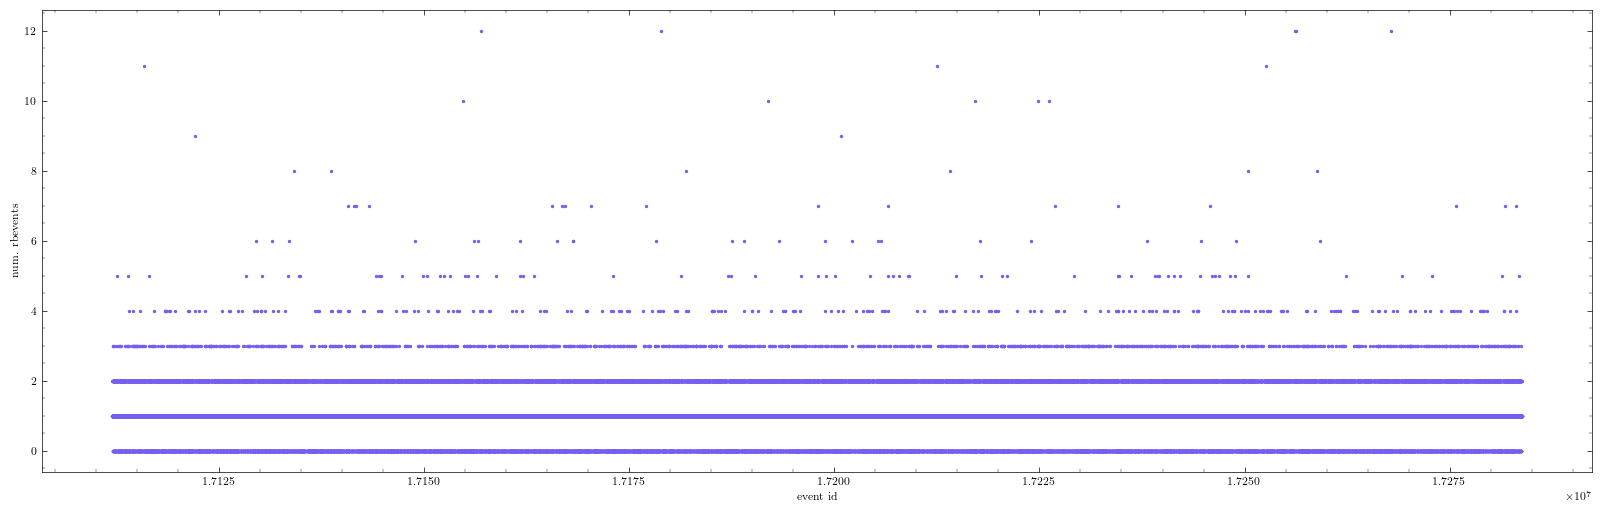

In [58]:


plt.figure(figsize = (20,6))
plt.scatter(data_dict['evtid'][2060438:2232140], data_dict['num_rbe'][2060438:2232140], s = 2)
#plt.title('Paddle 97B charge over time')
plt.xlabel('event id')
plt.ylabel('num. rbevents')
plt.minorticks_on()
plt.show()

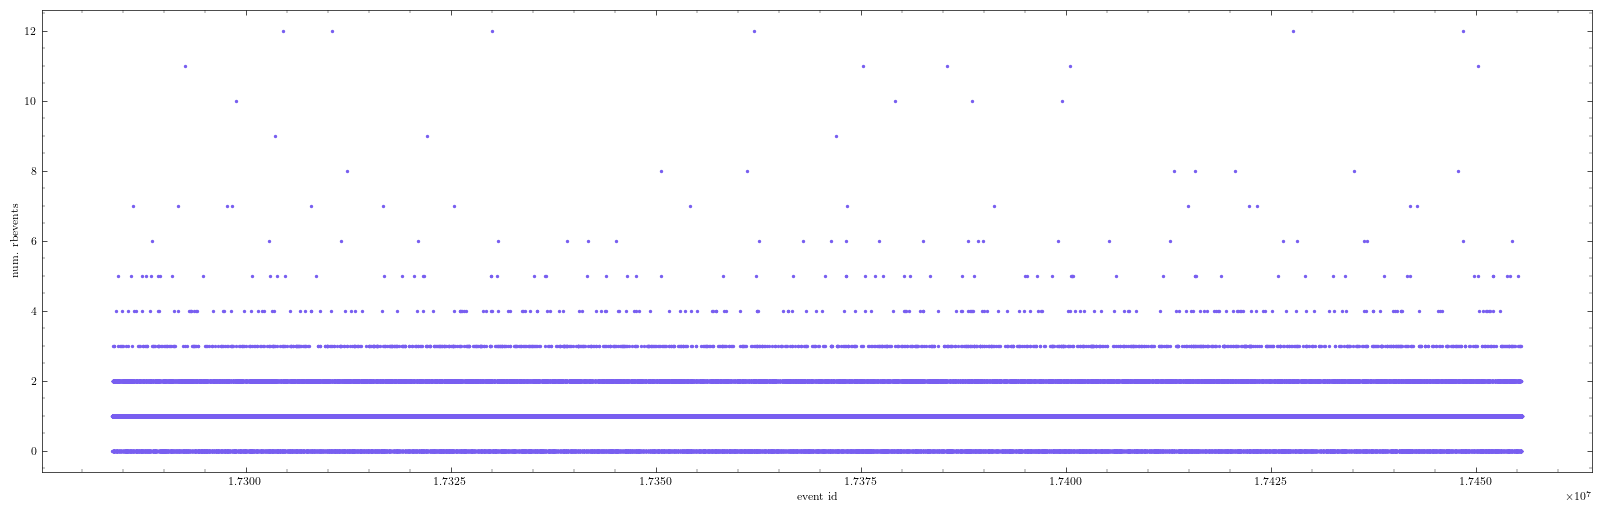

In [60]:
2403843

plt.figure(figsize = (20,6))
plt.scatter(data_dict['evtid'][2232141:2403843], data_dict['num_rbe'][2232141:2403843], s = 2)
#plt.title('Paddle 97B charge over time')
plt.xlabel('event id')
plt.ylabel('num. rbevents')
plt.minorticks_on()
plt.show()

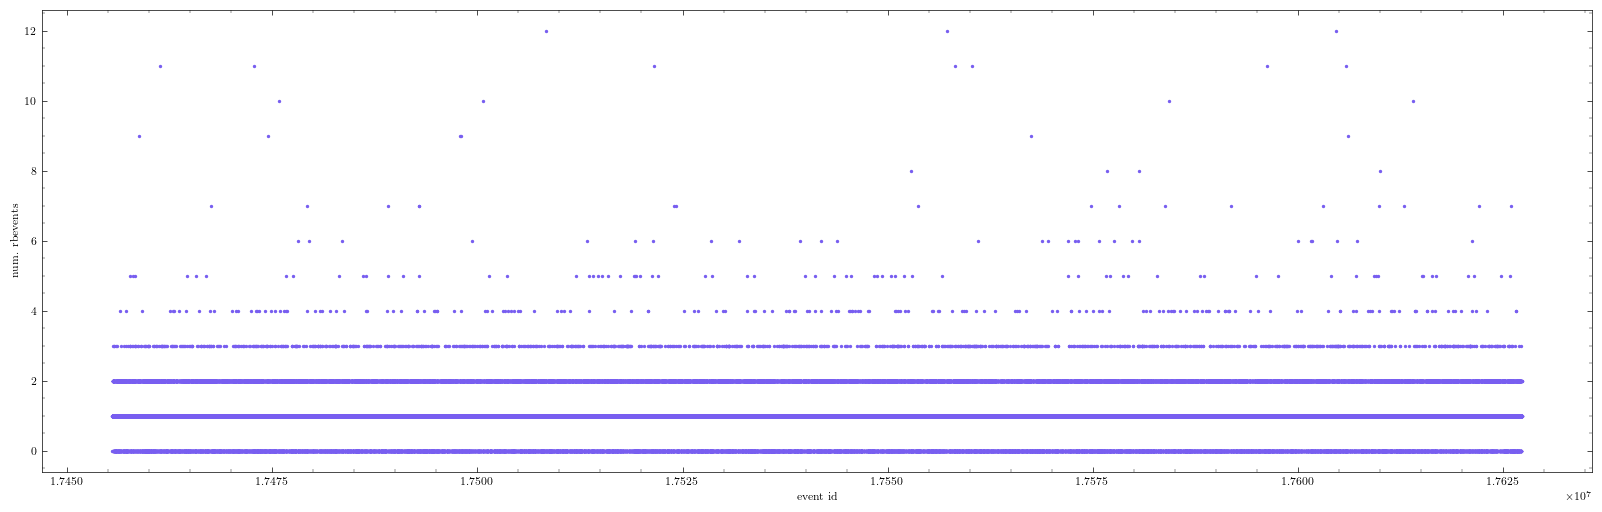

In [62]:
2575546

plt.figure(figsize = (20,6))
plt.scatter(data_dict['evtid'][2403844:2575546], data_dict['num_rbe'][2403844:2575546], s = 2)
#plt.title('Paddle 97B charge over time')
plt.xlabel('event id')
plt.ylabel('num. rbevents')
plt.minorticks_on()
plt.show()

In [64]:
index = next((i for i, x in enumerate(data_dict['num_rbe']) if x != 0), None)

In [65]:
index

1171

In [66]:
data_dict['evtid'][1171]

np.float64(15052265.0)